In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [10]:
df = pd.read_csv('Titanic-Dataset.csv')
#loading and cleaning the data

# Handle missing values: 
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#Drop columns that don't help the model find survival patterns (Names, IDs, Tickets)
df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True, errors='ignore')
df


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [11]:
#preprocessing the data
le = LabelEncoder()
# Initialize the LabelEncoder to convert 'Sex' (male/female) into numbers (0/1)
df['Sex'] = le.fit_transform(df['Sex']) # 0 for female, 1 for male
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,False,True
887,1,1,0,19.0,0,0,30.0000,False,True
888,0,3,0,28.0,1,2,23.4500,False,True
889,1,1,1,26.0,0,0,30.0000,False,False


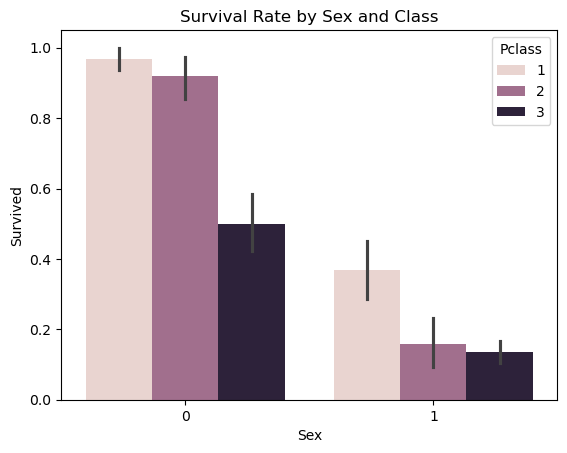

In [12]:
# Create a bar chart to see how Class and Sex affected survival rates 
sns.barplot(x='Sex', y='Survived', hue='Pclass', data=df)
plt.title('Survival Rate by Sex and Class')
plt.show()

In [13]:
# Splitting and Scaling
# Separate the target 'Survived' (y) from the features (X)
X = df.drop('Survived', axis=1)
y = df['Survived']
# Split data: 80% for training the model, 20% for testing it later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data so that large numbers (Fare) don't overpower small numbers (Age)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Initialize and train 
# Initialize the model using 100 decision trees (default)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Save the model
joblib.dump(rf_model, 'titanic_rf_model.pkl')
print("Model saved as titanic_rf_model.pkl")

Model saved as titanic_rf_model.pkl


In [17]:
from sklearn.model_selection import GridSearchCV

# Define a 'grid' of settings to see which combination works best
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Run the search: it tests every setting combination using 5-fold Cross-Validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
# Identify the best version of the model from the search results
best_model = grid_search.best_estimator_
print(f"Section 3: Best settings found: {grid_search.best_params_}")

Section 3: Best settings found: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [24]:
from sklearn.metrics import classification_report

# 1. Final Analysis
predictions = best_model.predict(X_test_scaled)
print(classification_report(y_test, predictions))

# 2. THE OUTPUT FUNCTION
def predict_survival(pclass, sex, age, sibsp, parch, fare, emb_q, emb_s):
    # We must scale the new input data exactly like the training data
    person = [[pclass, sex, age, sibsp, parch, fare, emb_q, emb_s]]
    person_scaled = scaler.transform(person)
    
    result = best_model.predict(person_scaled)
    return "Survived" if result[0] == 1 else "Did Not Survive"

# Sample Output
print(predict_survival(3, 1, 22, 1, 0, 7.25, 0, 1))


              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179

Did Not Survive


C:\Users\Dev Pranesh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
